## Figure 1 — Electromagnetic modes in a 1D cavity and their quantized energy spectrum

This notebook reproduces **Figure 1** of the paper.

A 1D electromagnetic cavity of length $L = 10^{-10}$ m (one atomic diameter, chosen to place mode frequencies in the optical range) admits standing-wave modes
$$\phi_m(x) = \sin(k_m x), \quad k_m = \frac{m\pi}{L}, \quad m = 1, 2, 3, \ldots$$

### Left panel — Standing wave modes $\phi_m(x)$
Plots the first three cavity modes.

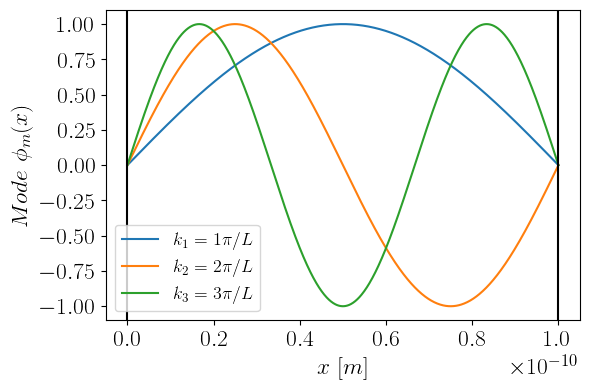

In [3]:
# box_light_modes_with_box.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Parameters
L = 1e-10
x = np.linspace(0, L, 1000)
m_vals = [1, 2, 3]

fonty = 17
fig1 = plt.figure(1,figsize=(6,4))
plt.rc('text', usetex=True)

# Plot first three modes
for m in m_vals:
    k = np.pi * m / L
    y = np.sin(k * x)
    plt.plot(x, y, label=fr"$k_{m}={m}\pi/L$")

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax.xaxis.get_offset_text().set_fontsize(fonty)  # adjust size of 10^ exponent

    
# Add box boundaries
plt.axvline(0, color="black", lw=1.5)
plt.axvline(L, color="black", lw=1.5)
#plt.axhline(0, color="black", lw=0.8)

plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$x$ $[m]$', fontsize=fonty)  # x-axis: a
plt.ylabel(r'$Mode$ $\phi_m(x)$', fontsize=fonty)  # x-axis: a
plt.xlim(-0.05*1e-10, L+0.05*1e-10)
plt.ylim(-1.1, 1.1)
plt.legend(fontsize=fonty-4, loc='best')
plt.tight_layout()
fig1 = plt.gcf()
plt.show()


fig1.savefig('box_light_modes_with_box.png', format='png', dpi=1000, bbox_inches='tight')
#plt.close()

### Right panel — Quantized energy spectrum $\mathcal{H}_m^{n_m}$

Each mode frequency $\omega_m = c k_m$ supports a quantum harmonic oscillator energy ladder:
$$\mathcal{H}_m^{n_m} = \left(n_m + \tfrac{1}{2}\right)\hbar\omega_m, \quad n_m = 0, 1, 2, \ldots$$
The total field energy is $E = \sum_m \mathcal{H}_m^{n_m}$. Dots mark allowed energies at the five discrete frequencies $\omega_1, \ldots, \omega_5$; dashed lines show the continuous dependence on $\omega$.

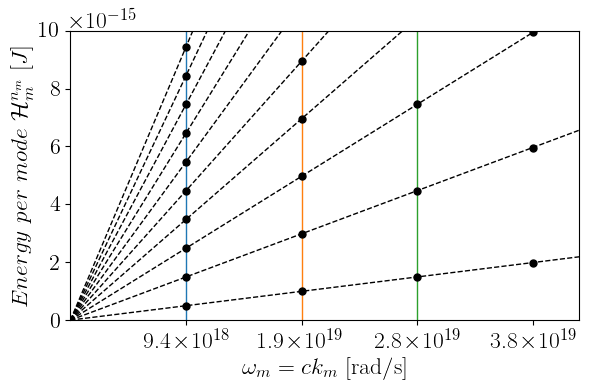

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter

# Parameters
m_vals = np.arange(1, 6)   # discrete frequencies (mode indices)
n_vals = np.arange(0, 10)  # quantum numbers n

hbar = 1.05457182e-34
L = 1e-10
c = 300000000
omega_m = m_vals * np.pi * c / L   # actual discrete frequencies

fonty = 17
fig2 = plt.figure(2, figsize=(6,4))
plt.rc('text', usetex=True)

plt.axvline(x=omega_m[0], color='tab:blue', linestyle='-', linewidth=1.)
plt.axvline(x=omega_m[1], color='tab:orange', linestyle='-', linewidth=1.)
plt.axvline(x=omega_m[2], color='tab:green', linestyle='-', linewidth=1.)

# Plot discrete black dots: E = (n+1/2)ħω_m
for n in n_vals:
    E = (n + 0.5) * hbar * omega_m
    plt.plot(omega_m, E, 'ko', markersize=5)

# Plot dashed lines: E = n ħ ω (continuous ω)
omega_cont = np.linspace(0, omega_m[-1]*1.1, 400)
for n in n_vals:
    E_line = (n + 0.5) * hbar * omega_cont
    plt.plot(omega_cont, E_line, 'k--', lw=1)

plt.yticks(size=fonty)

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.yaxis.get_offset_text().set_fontsize(fonty)

# ---- Custom formatter for ω_m ticks ----
def sci_notation(val, pos):
    s = f"{val:.1e}"
    base, exp = s.split("e")
    return rf"$\textnormal{{{base}}} \! \times \! 10^{{{int(exp)}}}$"

# place ticks exactly at omega_m
ax.set_xticks(omega_m)
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))

plt.xticks(fontsize=fonty)
plt.yticks(fontsize=fonty-1)

# ---- Axis labels ----
plt.xlabel(r'$\omega_m = ck_m \; [\mathrm{rad/s}]$', fontsize=fonty)
plt.ylabel(r'$Energy$ $per$ $mode$ $\mathcal{H}_m^{n_m}$ $[J]$', fontsize=fonty)

plt.xlim(0, omega_m[3]*1.1)
plt.ylim(0, 1e-14)
plt.tight_layout()

fig2 = plt.gcf()
plt.show()

fig2.savefig('quantum_energy_box.png', format='png', dpi=1000, bbox_inches='tight')


## By Arnaud Lazarus - 06/13/2026